<a href="https://colab.research.google.com/github/neha1148/catalyst-assingment/blob/main/rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import zipfile

# Path to the zip file
zip_file_path = "WineQT.csv.zip"

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn import metrics
print('acuraccy score: ',metrics.accuracy_score(y_test,y_pred))

acuraccy score:  0.6899563318777293


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
model = RandomForestRegressor(n_estimators=100)
cross_val_score(model,X,y)

array([0.28711558, 0.37912989, 0.37379934, 0.35438396, 0.26544625])

[Text(0.6390778033698539, 0.9722222222222222, 'x[10] <= 10.65\ngini = 0.641\nsamples = 579\nvalue = [3, 35, 403, 351, 114, 8]'),
 Text(0.440464703685259, 0.9166666666666666, 'x[6] <= 69.5\ngini = 0.523\nsamples = 358\nvalue = [3, 24, 353, 170, 19, 0]'),
 Text(0.5397712535275564, 0.9444444444444444, 'True  '),
 Text(0.27867177124834, 0.8611111111111112, 'x[9] <= 0.585\ngini = 0.571\nsamples = 267\nvalue = [3.0, 19.0, 226.0, 146.0, 19.0, 0.0]'),
 Text(0.0947875166002656, 0.8055555555555556, 'x[8] <= 3.135\ngini = 0.453\nsamples = 106\nvalue = [3.0, 11.0, 124.0, 32.0, 4.0, 0.0]'),
 Text(0.08947543160690571, 0.75, 'gini = 0.0\nsamples = 9\nvalue = [0, 0, 16, 0, 0, 0]'),
 Text(0.10009960159362549, 0.75, 'x[5] <= 17.5\ngini = 0.486\nsamples = 97\nvalue = [3, 11, 108, 32, 4, 0]'),
 Text(0.042164674634794154, 0.6944444444444444, 'x[1] <= 0.455\ngini = 0.456\nsamples = 83\nvalue = [1, 11, 99, 24, 4, 0]'),
 Text(0.01593625498007968, 0.6388888888888888, 'x[7] <= 0.996\ngini = 0.491\nsamples = 19\

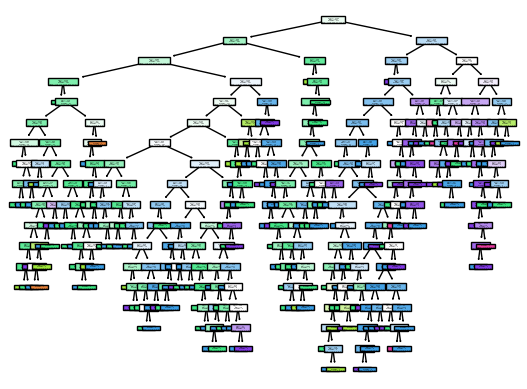

In [ ]:
from sklearn import tree
tree.plot_tree(model.estimators_[0], filled=True)

In [ ]:
from sklearn.model_selection import validation_curve

In [ ]:
param_range=np.arange(1,200,2)

In [ ]:
train_scores, test_scores = validation_curve(RandomForestClassifier(),
                                             X,y,param_name="n_estimators",param_range=param_range,
                                             cv=4,scoring="accuracy",n_jobs=-1)

In [ ]:
train_mean=np.mean(train_scores,axis=1)
train_std=np.std(train_scores,axis=1)
test_mean=np.mean(test_scores,axis=1)
test_std=np.std(test_scores,axis=1)

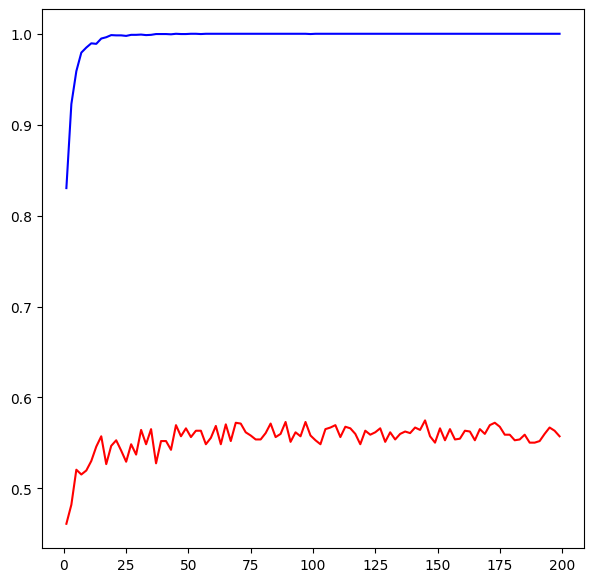

In [ ]:
plt.subplots(figsize=(7,7))
plt.plot(param_range,train_mean,label="Training Score",color="blue")
plt.plot(param_range,test_mean,label="Cross Validation Score",color="red")